In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

from func_data_prep import process_string, scale_feature_by_daily_intake, get_var_type, get_var_type_color
from func_modeling import calculate_vif, run_all_diagnostics, try_transformations, recommend_transformation, back_transform_effects
from statsmodels.formula.api import mixedlm

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load data


In [2]:
meta = pd.read_csv("../data/meta_meal_patterns.csv")

meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

In [3]:
merged_meals_with_meta = pd.read_pickle("../data/merged_meals_with_meta.pkl")

# merged_meals_with_meta = merged_meals_with_meta[
#     merged_meals_with_meta["energy_kcal_eaten"] > 250
# ]

merged_meals_with_meta["eaten_at"] = pd.to_datetime(merged_meals_with_meta["eaten_at"])
merged_meals_with_meta["eaten_date"] = pd.to_datetime(
    merged_meals_with_meta["eaten_at"].dt.date
)

# # Extract the hour from 'local_eaten_at'
# merged_meals_with_meta['eaten_hour'] = merged_meals_with_meta['local_eaten_at'].dt.hour

print(merged_meals_with_meta.shape)

(65838, 205)


### Scale the energy distribution by meal & Plot correlation

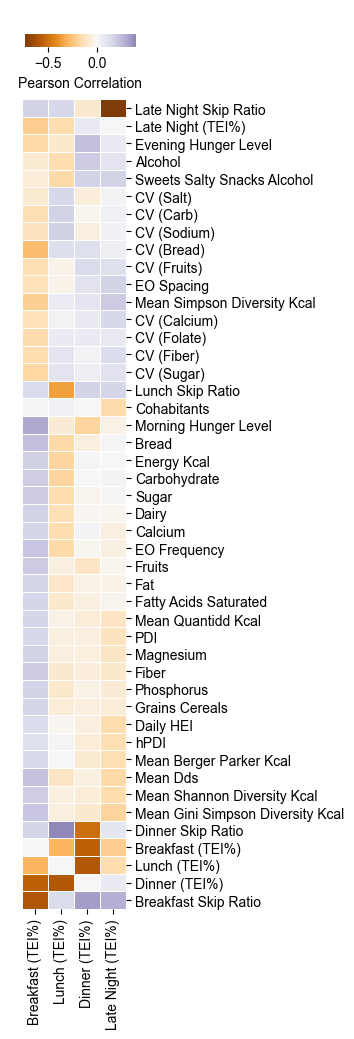

In [4]:
# Scale the energy distribution by meal type
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]

scaled_energy_distribution = scale_feature_by_daily_intake(
    mmm_no_small, "energy_kcal_eaten"
)

meal_cols = ["Breakfast", "Lunch", "Dinner", "Late_night"]
meal_tei_cols = [col + " (TEI%)" for col in meal_cols]
rename_dict = {
    col: f"{col.replace('_', ' ').title()} (TEI%)"
    for col in meal_cols
    if col in scaled_energy_distribution.columns
}
scaled_energy_distribution.rename(columns=rename_dict, inplace=True)
meal_tei_cols = list(rename_dict.values())

# Calculate the mean of scaled energy distribution and merge with metadata
scaled_energy_distribution_mean_with_meta = (
    scaled_energy_distribution.drop(columns=["eaten_date"])
    .groupby("subject_key")
    .mean()
    .merge(meta, left_index=True, right_on="subject_key", how="inner")
)

# Compute correlations for meal types and filter based on threshold
corrs_meal_type = scaled_energy_distribution_mean_with_meta.corr(numeric_only=True)[
    meal_tei_cols
]
corrs_meal_type = corrs_meal_type[(corrs_meal_type.abs() >= 0.15).any(axis=1)]
corrs_meal_type = corrs_meal_type[
    ~corrs_meal_type.index.isin(
        ["alcohol_fg_eaten", "energy_kj_eaten", "others_fg_eaten"]
    )
]

for meal_type in meal_tei_cols:
    corrs_meal_type.loc[meal_type, meal_type] = 0

# Determine row colors based on variable type
row_colors = [
    get_var_type_color(get_var_type(index)) for index in corrs_meal_type.index
]

# Create a clustered heatmap
g = sns.clustermap(
    data=corrs_meal_type,
    cmap="PuOr",
    center=0,
    figsize=(3.7, 10.5),
    col_cluster=False,
    # row_colors=row_colors,
    dendrogram_ratio=0.1,
    linewidths=0.5,
    cbar_kws={"orientation": "horizontal", "label": "Pearson Correlation"},
    row_cluster=True,
    tree_kws={"linewidths": 0},  # Hide row cluster linkages
)

# Adjust the position and size of the color bar
g.cax.set_position([0.08, 0.95, 0.3, 0.012])

# Process and set y-axis labels
new_labels = [
    process_string(str(label.get_text()))
    for label in g.ax_heatmap.yaxis.get_majorticklabels()
]
g.ax_heatmap.set_yticklabels(new_labels)
g.ax_heatmap.set_ylabel("")

# Rotate x-axis labels for better readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)

# Save the figure
g.savefig("../images/fig2/mealtype_EI_heatmap.png", dpi=300, bbox_inches="tight")

In [5]:
corrs_meal_type

,Breakfast (TEI%),Lunch (TEI%),Dinner (TEI%),Late Night (TEI%)
Breakfast (TEI%),0.000000,-0.297750,-0.555525,-0.214000
Dinner (TEI%),-0.555525,-0.591238,0.000000,0.066134
Late Night (TEI%),-0.214000,-0.159868,0.066134,0.000000
Lunch (TEI%),-0.297750,0.000000,-0.591238,-0.159868
cohabitants,0.008924,0.035926,0.003284,-0.163324
morning_hunger_level,0.304097,-0.079267,-0.185412,-0.041001
evening_hunger_level,-0.171121,-0.098290,0.223232,0.057153
PDI_Quintile,0.152294,-0.053680,-0.051063,-0.130981
hPDI_Quintile,0.114699,0.011815,-0.070823,-0.152998
energy_kcal_eaten,0.177467,-0.190291,0.013054,0.005093


### Model meal type energy intake w.r.t health outcomes

In [6]:
def analyze_mealtype_energy_intake_wrt_health_outcomes(
    df, meta_df, meal_var, outcome_var, covariates=None
):
    """
    Analyze relationship between meal timing and health outcomes using Mixed Linear Models.
    Uses statsmodels formula interface for easier model specification.

    Parameters:
    -----------
    df : pandas DataFrame
        Main dataframe containing meal timing data
    meta_df : pandas DataFrame
        Metadata dataframe containing subject characteristics
    meal_var : str
        Name of the meal variable to analyze (e.g., 'Breakfast')
    outcome_var : str
        Name of the outcome variable (e.g., 'bmi')
    covariates : list, optional
        List of covariate column names to include in model
    """
    # Merge the dataframes
    merged_df = df.merge(meta_df, on="subject_key", how="inner")

    # Calculate subject-level meal timing averages
    subject_means = merged_df.groupby("subject_key")[meal_var].mean().reset_index()
    merged_df = merged_df.merge(subject_means, on="subject_key", suffixes=("", "_mean"))

    # Create formula string
    if covariates:
        formula = f"{outcome_var} ~ {meal_var}_mean + {' + '.join(covariates)}"
    else:
        formula = f"{outcome_var} ~ {meal_var}_mean"

    try:
        # Fit mixed linear model
        model = mixedlm(formula, merged_df, groups=merged_df["subject_key"])
        result = model.fit()

        # Calculate additional statistics
        n_subjects = len(merged_df["subject_key"].unique())
        n_observations = len(merged_df)

        # Calculate correlation
        correlation = merged_df[[f"{meal_var}_mean", outcome_var]].corr().iloc[0, 1]

        # Create summary dictionary
        summary = {
            "model_summary": result.summary(),
            "fixed_effects": result.fe_params,
            "random_effects": result.random_effects,
            "aic": result.aic,
            "bic": result.bic,
            "n_subjects": n_subjects,
            "n_observations": n_observations,
            "correlation": correlation,
            "p_values": result.pvalues,
            "confidence_intervals": result.conf_int(),
        }

        return summary

    except Exception as e:
        print(f"\nError fitting model: {str(e)}")
        print(f"Formula used: {formula}")
        print("Available columns:", merged_df.columns.tolist())
        return None


def run_analyze_mealtype_energy_intake_wrt_health_outcomes(
    df,
    meta_df,
    outcome_var,
    covariates=None,
    verbose=False,
    meal_types=None,
):
    """
    Run analysis for all meal types and compile results.

    Parameters:
    -----------
    df : pandas DataFrame
        Main dataframe containing meal timing data
    meta_df : pandas DataFrame
        Metadata dataframe containing subject characteristics
    outcome_var : str
        Name of the outcome variable (e.g., 'BMI')
    covariates : list, optional
        List of covariate column names to include in model
    """
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
    results = {}

    for meal in meal_types:
        results[meal] = analyze_mealtype_energy_intake_wrt_health_outcomes(
            df, meta_df, meal_var=meal, outcome_var=outcome_var, covariates=covariates
        )

        if results[meal] and verbose:
            print(f"\nAnalyzed {meal}...")
            print("\nModel Summary:")
            print(results[meal]["model_summary"])

    return results

In [7]:
def get_significance_stars(p_value):
    """Helper function to return significance stars"""
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return ""


def plot_mealtype_energy_intake_effects(
    results,
    ax,
    target_var,
    meal_types=None,
):
    """
    Plot fixed effects with confidence intervals for meal timing analysis.

    Parameters:
    -----------
    results : dict
        Dictionary containing results from meal timing analysis
        Each meal type should have 'fixed_effects', 'confidence_intervals', and 'p_values'
    meal_types : list, optional
        List of meal types to plot. If None, uses all available meals
    figsize : tuple, optional
        Figure size in inches

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    if meal_types is None:
        meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    # Prepare data
    effects_data = []
    for meal in meal_types:
        if meal in results:
            # Get fixed effect for meal timing
            effect = results[meal]["fixed_effects"][f"{meal}_mean"]

            # Get confidence intervals for meal timing
            ci = results[meal]["confidence_intervals"]
            ci_low = ci.loc[f"{meal}_mean", 0]
            ci_high = ci.loc[f"{meal}_mean", 1]

            # Get p-value
            p_value = results[meal]["p_values"][f"{meal}_mean"]

            effects_data.append(
                {
                    "meal": meal,
                    "effect": effect,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "p_value": p_value,
                }
            )

    # Convert to DataFrame for easier plotting
    df = pd.DataFrame(effects_data)

    # Create color mapping
    # colors = ['#2196F3', '#4CAF50', '#FFC107', '#FF5722']
    bar_colors = [
        "steelblue" if effect >= 0 else "darkorange" for effect in df["effect"]
    ]
    # bar_colors = ['limegreen' if effect >= 0 else 'salmon' for effect in df['effect']]

    # Plot bars
    bars = ax.bar(
        range(len(df)),
        df["effect"],
        # color= colors[:len(df)],
        color=bar_colors,
        width=0.5,
        alpha=0.7,
    )

    # Add error bars
    ax.errorbar(
        range(len(df)),
        df["effect"],
        yerr=[df["effect"] - df["ci_low"], df["ci_high"] - df["effect"]],
        fmt="none",
        color="black",
        capsize=4,
        capthick=0.75,
        elinewidth=0.75,
    )

    # Customize plot
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([f"{meal}\n(TEI%)" for meal in df["meal"]], rotation=0)

    # Add labels and title
    # ax.set_xlabel('Meal Type', fontsize=12)
    ax.set_ylabel(
        f"Effect on {process_string(target_var)} (β coefficient)", fontsize=11
    )
    # ax.set_title('Associations Between Meal Timing and BMI\nEffect sizes with 95% confidence intervals',
    #             fontsize=14, pad=20)

    # Add grid
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # Add significance stars
    max_effect = df["effect"].max()
    min_effect = df["effect"].min()
    y_range = max_effect - min_effect

    for i, row in df.iterrows():
        stars = get_significance_stars(row["p_value"])
        if stars:
            # Position stars above the error bars
            if row["effect"] >= 0:
                y_pos = row["ci_high"] + 0.5 * y_range * 0.05
            else:
                y_pos = row["ci_low"] - 2 * y_range * 0.05
            ax.text(i, y_pos, stars, ha="center", va="bottom", fontsize=12)

    # # Add legend for significance levels
    # legend_text = 'Significance levels:\n**** p < 0.001\n** p < 0.01\n* p < 0.05'
    # fig.text(0.5, 0.8, legend_text,
    #          ha='right', va='bottom', fontsize=10, style='italic')

    return ax

In [8]:
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]

# mmm_no_small = (
#     mmm_no_small.groupby(["subject_key", "eaten_date", "meal_type"])
#     .apply(lambda x: x.loc[x["energy_kcal_eaten"].idxmax()], include_groups=False)
#     .reset_index(drop=False)
# )

scaled_energy_distribution = scale_feature_by_daily_intake(
    mmm_no_small, "energy_kcal_eaten"
)

scaled_energy_distribution["eaten_date"] = pd.to_datetime(
    scaled_energy_distribution["eaten_date"]
)
scaled_energy_distribution["day_of_week"] = scaled_energy_distribution[
    "eaten_date"
].dt.dayofweek
scaled_energy_distribution["is_weekend"] = scaled_energy_distribution[
    "day_of_week"
].isin([5, 6])
### scaled_energy_distribution, result = analyze_meal_weekend_effect_with_ks(scaled_energy_distribution, 'Dinner')

Note: Mealtype values are taken as averages over the days for each subject.


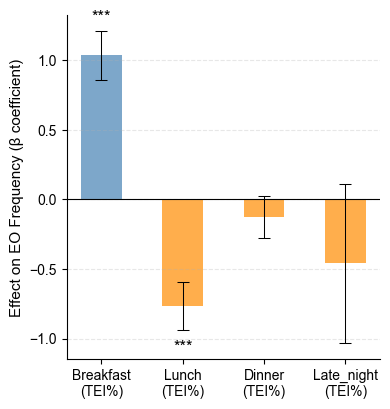

In [9]:
print("Note: Mealtype values are taken as averages over the days for each subject.")

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 4.2))

outcome_var = "eo_freq"
lmm_results_mealtype_energy_intake_eo_freq = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["age", "bmi", "gender", "energy_kcal_eaten"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_eo_freq,
    ax,
    outcome_var,
)

plt.tight_layout()
sns.despine()

plt.savefig(
    "../images/fig2/mealtype_energy_intake_effects_EOfreq.png",
    dpi=300,
    bbox_inches="tight",
)

In [27]:
print(lmm_results_mealtype_energy_intake_eo_freq["Late_night"]["model_summary"])
print(lmm_results_mealtype_energy_intake_eo_freq["Dinner"]["model_summary"])
print(lmm_results_mealtype_energy_intake_eo_freq["Lunch"]["model_summary"])
print(lmm_results_mealtype_energy_intake_eo_freq["Late_night"]["model_summary"])

            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  eo_freq    
No. Observations:   13385    Method:              REML       
No. Groups:         962      Scale:               0.0000     
Min. group size:    5        Log-Likelihood:      145972.3290
Max. group size:    28       Converged:           Yes        
Mean group size:    13.9                                     
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          1.893    0.061  31.121 0.000  1.774  2.012
gender[T.male]    -0.536    0.015 -35.649 0.000 -0.565 -0.506
Late_night_mean   -0.461    0.293  -1.575 0.115 -1.034  0.113
age                0.010    0.001  17.257 0.000  0.009  0.011
bmi               -0.018    0.002  -9.534 0.000 -0.022 -0.014
energy_kcal_eaten  0.001    0.000  81.995 0.000  0.001  0.002
Group Var          0

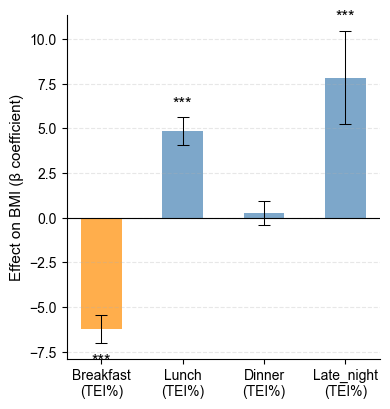

In [29]:
# print("Note: Mealtype values are taken as averages over the days for each subject.")

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 4.2))

outcome_var = "bmi"
lmm_results_mealtype_energy_intake_bmi = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["age", "eo_freq", "gender", "energy_kcal_eaten"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_bmi,
    ax,
    outcome_var,
)

plt.tight_layout()
sns.despine()

# Save the plot if needed
plt.savefig(
    "../images/fig2/mealtype_energy_intake_effects_BMI.png",
    dpi=300,
    bbox_inches="tight",
)

In [30]:
print(lmm_results_mealtype_energy_intake_bmi["Late_night"]["model_summary"])
print(lmm_results_mealtype_energy_intake_bmi["Dinner"]["model_summary"])
print(lmm_results_mealtype_energy_intake_bmi["Lunch"]["model_summary"])
print(lmm_results_mealtype_energy_intake_bmi["Breakfast"]["model_summary"])

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  bmi        
No. Observations:  13385    Method:              REML       
No. Groups:        962      Scale:               0.0000     
Min. group size:   5        Log-Likelihood:      125648.0900
Max. group size:   28       Converged:           Yes        
Mean group size:   13.9                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         20.628    0.226 91.460 0.000 20.186 21.070
gender[T.male]     0.837    0.071 11.723 0.000  0.697  0.977
Late_night_mean    7.845    1.334  5.881 0.000  5.231 10.460
age                0.067    0.003 24.945 0.000  0.061  0.072
eo_freq           -0.375    0.039 -9.532 0.000 -0.452 -0.298
energy_kcal_eaten  0.001    0.000  8.387 0.000  0.001  0.001
Group Var          0.921 1468.034   

In [13]:
# print("Note: Mealtype values are taken as averages over the days for each subject.")

# fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(7, 4))

# outcome_var = "bmi"
# lmm_results_mealtype_energy_intake_bmi = run_analyze_mealtype_energy_intake_wrt_health_outcomes(
#     scaled_energy_distribution,
#     meta,
#     outcome_var=outcome_var,
#     covariates=["age", "eo_freq", "gender"],
#     # meal_types=meal_tei_cols,
# )
# plot_mealtype_energy_intake_effects(
#     lmm_results_mealtype_energy_intake_bmi,
#     ax[0],
#     outcome_var,
#     # meal_types=meal_tei_cols,
# )

# outcome_var = "eo_freq"
# lmm_results_mealtype_energy_intake_eo_freq = run_analyze_mealtype_energy_intake_wrt_health_outcomes(
#     scaled_energy_distribution,
#     meta,
#     outcome_var=outcome_var,
#     covariates=["age", "bmi", "gender"],
#     # meal_types=meal_tei_cols,
# )
# plot_mealtype_energy_intake_effects(
#     lmm_results_mealtype_energy_intake_eo_freq,
#     ax[1],
#     outcome_var,
#     # meal_types=meal_tei_cols,
# )

# plt.tight_layout()
# sns.despine()

# # Save the plot if needed
# plt.savefig(
#     "../images/fig2/mealtype_energy_intake_effects.png", dpi=300, bbox_inches="tight"
# )

Note: Mealtype values are taken as averages over the days for each subject.


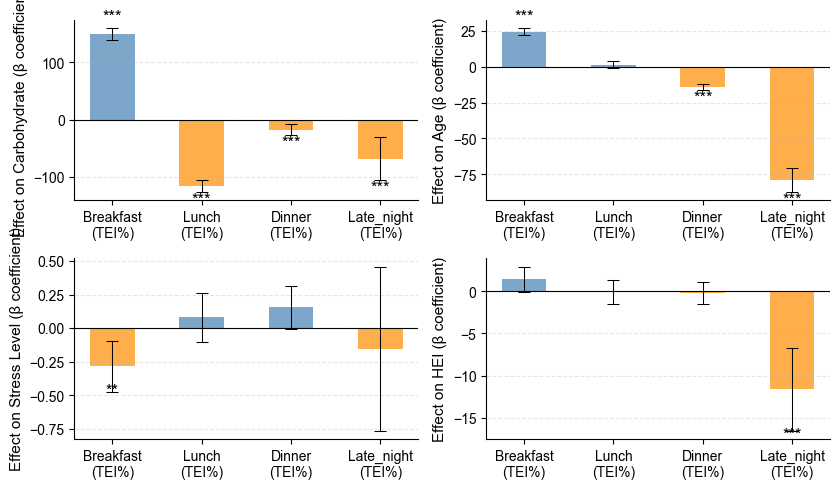

In [ ]:
print("Note: Mealtype values are taken as averages over the days for each subject.")

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8.5, 5))

outcome_var = "carb_eaten"
lmm_results_mealtype_energy_intake_bmi_carb = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["age", "gender"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_bmi_carb, ax[0, 0], outcome_var
)

outcome_var = "age"
lmm_results_mealtype_energy_intake_age = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["bmi", "gender", "energy_kcal_eaten"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_age, ax[0, 1], outcome_var
)

outcome_var = "stress_level"
lmm_results_mealtype_energy_intake_stress_level = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["age", "bmi", "gender", "energy_kcal_eaten"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_stress_level, ax[1, 0], outcome_var
)

outcome_var = "HEI"
lmm_results_mealtype_energy_intake_HEI = (
    run_analyze_mealtype_energy_intake_wrt_health_outcomes(
        scaled_energy_distribution,
        meta,
        outcome_var=outcome_var,
        covariates=["age", "bmi", "gender"],
    )
)
plot_mealtype_energy_intake_effects(
    lmm_results_mealtype_energy_intake_HEI,
    ax[1, 1],
    outcome_var,
)

plt.tight_layout()
sns.despine()

# Save the plot if needed
plt.savefig(
    "../images/supplementary/mealtype_energy_intake_effects_others.png",
    dpi=300,
    bbox_inches="tight",
)

In [15]:
meal_tei_cols

['Breakfast (TEI%)', 'Lunch (TEI%)', 'Dinner (TEI%)', 'Late Night (TEI%)']

In [16]:
print(lmm_results_mealtype_energy_intake_bmi["Breakfast"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_bmi["Lunch"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_bmi["Dinner"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_bmi["Late_night"]["fixed_effects"])

Intercept         238.608753
gender[T.male]     30.755483
Breakfast_mean    149.337735
age                -1.175724
dtype: float64 

Intercept         298.225543
gender[T.male]     29.566023
Lunch_mean       -115.687985
age                -1.028461
dtype: float64 

Intercept         263.559834
gender[T.male]     30.427412
Dinner_mean       -17.337574
age                -1.087450
dtype: float64 

Intercept          256.356200
gender[T.male]      30.586720
Late_night_mean    -67.663697
age                 -1.093602
dtype: float64


In [17]:
print(lmm_results_mealtype_energy_intake_eo_freq["Breakfast"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_eo_freq["Lunch"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_eo_freq["Dinner"]["fixed_effects"], "\n")
print(lmm_results_mealtype_energy_intake_eo_freq["Late_night"]["fixed_effects"])

Intercept            1.811545
gender[T.male]      -0.523953
Breakfast_mean       1.033774
age                  0.009264
bmi                 -0.015120
energy_kcal_eaten    0.001445
dtype: float64 

Intercept            2.199670
gender[T.male]      -0.535382
Lunch_mean          -0.764239
age                  0.010411
bmi                 -0.016302
energy_kcal_eaten    0.001460
dtype: float64 

Intercept            1.947681
gender[T.male]      -0.536850
Dinner_mean         -0.128173
age                  0.010257
bmi                 -0.018127
energy_kcal_eaten    0.001491
dtype: float64 

Intercept            1.892991
gender[T.male]      -0.535694
Late_night_mean     -0.460740
age                  0.010211
bmi                 -0.017994
energy_kcal_eaten    0.001490
dtype: float64


## Mediation analysis

In [18]:
def run_mediation_analysis(df, meta_df, meal_var, covariates=None):
    """
    Perform mediation analysis using mixed linear models to understand how eating frequency
    mediates the relationship between meal timing and BMI.

    Parameters:
    -----------
    df : pandas DataFrame
        Main dataframe containing meal timing data
    meta_df : pandas DataFrame
        Metadata dataframe containing subject characteristics
    meal_var : str
        Name of the meal variable to analyze (e.g., 'Breakfast')
    covariates : list, optional
        List of covariates to control for. Can include categorical variables.

    Returns:
    --------
    dict
        Dictionary containing mediation results and path coefficients
    """
    # Merge dataframes
    merged_df = df.merge(meta_df, on="subject_key", how="inner")

    # Calculate subject-level meal timing averages
    subject_means = merged_df.groupby("subject_key")[meal_var].mean().reset_index()
    merged_df = merged_df.merge(subject_means, on="subject_key", suffixes=("", "_mean"))

    try:
        # Prepare formula components
        covariate_str = " + ".join(covariates) if covariates else ""

        # Step 1: X → M (meal timing → eating frequency)
        formula_m = f"eo_freq ~ {meal_var}_mean + {covariate_str}"
        if covariate_str:
            formula_m = formula_m.strip(" + ")

        model_m = mixedlm(formula_m, data=merged_df, groups="subject_key")
        results_m = model_m.fit()
        a_path = results_m.params[f"{meal_var}_mean"]
        a_path_p = results_m.pvalues[f"{meal_var}_mean"]

        # Step 2: X + M → Y (meal timing + eating frequency → BMI)
        formula_y = f"bmi ~ {meal_var}_mean + eo_freq + {covariate_str}"
        if covariate_str:
            formula_y = formula_y.strip(" + ")

        model_y = mixedlm(formula_y, data=merged_df, groups="subject_key")
        results_y = model_y.fit()
        b_path = results_y.params["eo_freq"]
        b_path_p = results_y.pvalues["eo_freq"]
        c_prime_path = results_y.params[f"{meal_var}_mean"]
        c_prime_path_p = results_y.pvalues[f"{meal_var}_mean"]

        # Step 3: X → Y (total effect)
        formula_t = f"bmi ~ {meal_var}_mean + {covariate_str}"
        if covariate_str:
            formula_t = formula_t.strip(" + ")

        model_t = mixedlm(formula_t, data=merged_df, groups="subject_key")
        results_t = model_t.fit()
        c_path = results_t.params[f"{meal_var}_mean"]
        c_path_p = results_t.pvalues[f"{meal_var}_mean"]

        # Calculate indirect effect
        indirect_effect = a_path * b_path

        # Calculate proportion mediated
        prop_mediated = indirect_effect / c_path if c_path != 0 else 0

        # Prepare results
        results = {
            "a_path": {"coef": a_path, "p_value": a_path_p},
            "b_path": {"coef": b_path, "p_value": b_path_p},
            "c_path": {"coef": c_path, "p_value": c_path_p},
            "c_prime_path": {"coef": c_prime_path, "p_value": c_prime_path_p},
            "indirect_effect": indirect_effect,
            "total_effect": c_path,
            "direct_effect": c_prime_path,
            "proportion_mediated": prop_mediated,
            "model_summaries": {
                "path_a": results_m,
                "path_b": results_y,
                "total_effect": results_t,
            },
        }

        return results, merged_df

    except Exception as e:
        print(f"Error in mediation analysis: {str(e)}")
        return None, None


def analyze_all_meals_mediation(df, meta_df, covariates=None):
    """
    Run mediation analysis for all meal types.
    """
    meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
    results = {}

    for meal in meal_types:
        print(f"\nAnalyzing mediation for {meal}...")
        meal_results, _ = run_mediation_analysis(
            df, meta_df, meal_var=meal, covariates=covariates
        )

        if meal_results:
            results[meal] = meal_results
            # Create and save plot
            # fig, ax = plot_mediation_network(meal_results, meal)
            # plt.savefig(f'images/mediation/mediation_paths_{meal.lower()}.png',
            #            dpi=300, bbox_inches='tight')
            # plt.close()

    return results

In [19]:
import networkx as nx


def plot_mediation_network(results, meal_var, ax, figtext_pos=(0.02, 0.02)):
    """
    Visualize mediation analysis results using NetworkX.

    Parameters:
    -----------
    results : dict
        Dictionary containing mediation analysis results with paths and effects
    meal_var : str
        Name of the meal timing variable
    ax : matplotlib axis
        Axis to draw the network on
    figtext_pos : tuple
        Position for the summary statistics text (x, y)

    Returns:
    --------
    ax : matplotlib axis object
    """
    # Create directed graph
    G = nx.DiGraph()

    # Add nodes with labels
    nodes = [
        ("X", f'{" ".join(meal_var.split("_"))}\nTiming'),
        ("M", "Eating\nFrequency"),
        ("Y", "BMI"),
    ]
    G.add_nodes_from([node[0] for node in nodes])

    # Add edges with paths
    edges = [
        ("X", "M", {"path": "a", "data": results["a_path"]}),
        ("M", "Y", {"path": "b", "data": results["b_path"]}),
        ("X", "Y", {"path": "c'", "data": results["c_prime_path"]}),
    ]
    G.add_edges_from([(e[0], e[1], e[2]) for e in edges])

    # Set positions for nodes with more spacing
    pos = {"X": (-1, 0), "M": (0, 1), "Y": (1, 0)}

    # Set axis limits with padding
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    # Draw nodes
    node_colors = ["lightblue"] * len(G.nodes())
    node_size = 2000
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)

    # Draw node labels
    node_labels = dict(nodes)
    nx.draw_networkx_labels(G, pos, node_labels, font_size=10)

    # Function to add significance stars
    def get_stars(p_value):
        if p_value < 0.001:
            return "***"
        elif p_value < 0.01:
            return "**"
        elif p_value < 0.05:
            return "*"
        return ""

    # Draw edges with color based on beta value
    for edge in edges:
        source, target, data = edge
        beta = data["data"]["coef"]
        # Set color based on beta value
        color = "red" if beta < 0 else "black"

        # Draw curved arrows with appropriate color
        plt.annotate(
            "",
            xy=pos[target],
            xycoords="data",
            xytext=pos[source],
            textcoords="data",
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.2",
                color=color,  # Set arrow color
                lw=2,
                shrinkA=30,
                shrinkB=30,
            ),
        )

    # Add edge labels with path names, coefficients and significance
    edge_labels = {}
    for edge in edges:
        source, target, data = edge
        path_name = data["path"]
        coef = data["data"]["coef"]
        p_value = data["data"]["p_value"]
        # Color the beta value in the label text
        color = "red" if coef < 0 else "black"
        edge_labels[(source, target)] = {
            "text": f"Path {path_name}\nβ = {coef:.3f}{get_stars(p_value)}",
            "color": color,
        }

    # Calculate edge label positions with offset to avoid overlap with arrows
    edge_label_pos = {}
    for source, target in edge_labels.keys():
        source_pos = pos[source]
        target_pos = pos[target]
        mid_x = (source_pos[0] + target_pos[0]) / 2
        mid_y = (source_pos[1] + target_pos[1]) / 2

        # Add offset based on the path
        if source == "X" and target == "M":  # Path a
            mid_y += 0.2
        elif source == "M" and target == "Y":  # Path b
            mid_y += 0.2
        elif source == "X" and target == "Y":  # Path c'
            mid_y -= 0.2

        edge_label_pos[(source, target)] = (mid_x, mid_y)

    # Add edge labels at calculated positions with appropriate colors
    for (source, target), label_info in edge_labels.items():
        x, y = edge_label_pos[(source, target)]
        plt.text(
            x,
            y,
            label_info["text"],
            color=label_info["color"],
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )

    # Remove axis
    ax.set_axis_off()

    # Add effect sizes at specified position
    plt.figtext(
        figtext_pos[0],
        figtext_pos[1],
        f"Indirect effect (a×b): {results['indirect_effect']:.3f}\n"
        + f"Direct effect (c'): {results['c_prime_path']['coef']:.3f}\n"
        + f"Total effect (c): {results['total_effect']:.3f}\n"
        + f"Proportion mediated: {results['proportion_mediated']:.3f}",
        ha="left",
        va="bottom",
    )

    return ax

In [20]:
# Run the analysis
mediation_covariates = ["age", "gender", "energy_kcal_eaten"]
mediation_results = analyze_all_meals_mediation(
    scaled_energy_distribution, meta, covariates=mediation_covariates
)

print(mediation_results)

# Look at specific results
mediation_results_breakfast = mediation_results["Breakfast"]
print("\nBreakfast Mediation Results:")
print(
    f"Indirect effect: {mediation_results_breakfast['indirect_effect']:.3f}",
    "\t",
    f"Direct effect: {mediation_results_breakfast['direct_effect']:.3f}",
    "\t",
    f"Total effect: {mediation_results_breakfast['total_effect']:.3f}",
)

mediation_results_lunch = mediation_results["Lunch"]
print("\nLunch Mediation Results:")
print(
    f"Indirect effect: {mediation_results_lunch['indirect_effect']:.3f}",
    "\t",
    f"Direct effect: {mediation_results_lunch['direct_effect']:.3f}",
    "\t",
    f"Total effect: {mediation_results_lunch['total_effect']:.3f}",
)

mediation_results_dinner = mediation_results["Dinner"]
print("\nDinner Mediation Results:")
print(
    f"Indirect effect: {mediation_results_dinner['indirect_effect']:.3f}",
    "\t",
    f"Direct effect: {mediation_results_dinner['direct_effect']:.3f}",
    "\t",
    f"Total effect: {mediation_results_dinner['total_effect']:.3f}",
)

mediation_results_late_night = mediation_results["Late_night"]
print("\nLate Night Mediation Results:")
print(
    f"Indirect effect: {mediation_results_late_night['indirect_effect']:.3f}",
    "\t",
    f"Direct effect: {mediation_results_late_night['direct_effect']:.3f}",
    "\t",
    f"Total effect: {mediation_results_late_night['total_effect']:.3f}",
)


Analyzing mediation for Breakfast...

Analyzing mediation for Lunch...

Analyzing mediation for Dinner...

Analyzing mediation for Late_night...
{'Breakfast': {'a_path': {'coef': 1.1333882427321162, 'p_value': 5.187209200521322e-37}, 'b_path': {'coef': -0.3134164089007734, 'p_value': 1.4574333338146528e-15}, 'c_path': {'coef': -6.587291859744863, 'p_value': 3.434558838472186e-59}, 'c_prime_path': {'coef': -6.232069416498765, 'p_value': 8.562620574619265e-53}, 'indirect_effect': -0.35522247292745796, 'total_effect': -6.587291859744863, 'direct_effect': -6.232069416498765, 'proportion_mediated': 0.05392541889607671, 'model_summaries': {'path_a': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper object at 0x3436ebcd0>, 'path_b': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper object at 0x345a8d090>, 'total_effect': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper object at 0x345bc62d0>}}, 'Lunch': {'a_path': {'coef': -0.8478169172706763, 'p

In [21]:
mediation_results_breakfast

{'a_path': {'coef': 1.1333882427321162, 'p_value': 5.187209200521322e-37},
 'b_path': {'coef': -0.3134164089007734, 'p_value': 1.4574333338146528e-15},
 'c_path': {'coef': -6.587291859744863, 'p_value': 3.434558838472186e-59},
 'c_prime_path': {'coef': -6.232069416498765,
  'p_value': 8.562620574619265e-53},
 'indirect_effect': -0.35522247292745796,
 'total_effect': -6.587291859744863,
 'direct_effect': -6.232069416498765,
 'proportion_mediated': 0.05392541889607671,
 'model_summaries': {'path_a': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x3436ebcd0>,
  'path_b': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x345a8d090>,
  'total_effect': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x345bc62d0>}}

In [22]:
mediation_results_late_night

{'a_path': {'coef': -0.6060176772504622, 'p_value': 0.03871500420542625},
 'b_path': {'coef': -0.3749180612258006, 'p_value': 1.5446439559693888e-21},
 'c_path': {'coef': 8.071337232611977, 'p_value': 1.6269063690750951e-09},
 'c_prime_path': {'coef': 7.845162668905532, 'p_value': 4.078113556331815e-09},
 'indirect_effect': 0.22720697262330627,
 'total_effect': 8.071337232611977,
 'direct_effect': 7.845162668905532,
 'proportion_mediated': 0.028149854983791762,
 'model_summaries': {'path_a': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x345a8d150>,
  'path_b': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x348a6a050>,
  'total_effect': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x348e16350>}}

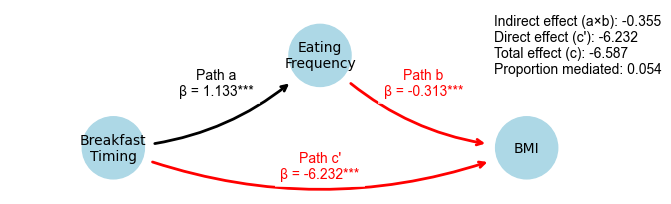

In [23]:
fig, ax = plt.subplots(figsize=(8, 2.4))
plot_mediation_network(
    mediation_results_breakfast, meal_var="Breakfast", ax=ax, figtext_pos=(0.73, 0.6)
)
plt.savefig(
    "../images/fig2/mediation_network_breakfast.png", dpi=300, bbox_inches="tight"
)
plt.show()

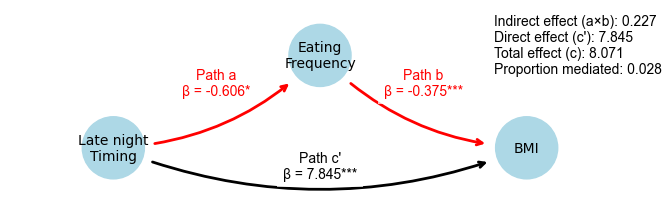

In [24]:
fig, ax = plt.subplots(figsize=(8, 2.4))
plot_mediation_network(
    mediation_results_late_night, meal_var="Late_night", ax=ax, figtext_pos=(0.73, 0.6)
)
plt.savefig(
    "../images/fig2/mediation_network_late_night.png", dpi=300, bbox_inches="tight"
)
plt.show()